In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys


In [40]:
df = pd.read_csv("merged_dataset.csv")
df.head()

,timestamp_ms,label,ax,ay,az,gx,gy,gz
0,1756360752472,SITTING,-0.92700,3.15495,9.64200,0.012238,-0.026537,-0.028600
1,1756360752483,SITTING,-0.93405,3.17700,9.53400,0.012238,-0.026537,-0.028600
2,1756360752504,SITTING,-0.83895,3.16005,9.42405,-0.066687,-0.321613,0.024612
3,1756360752518,SITTING,-0.73605,3.11205,9.42405,-0.071913,-0.250250,0.050188
4,1756360752538,SITTING,-0.43395,2.94705,9.26595,-0.033550,-0.109588,0.074663


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75263 entries, 0 to 75262
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp_ms  75263 non-null  int64  
 1   label         75263 non-null  str    
 2   ax            75263 non-null  float64
 3   ay            75263 non-null  float64
 4   az            75263 non-null  float64
 5   gx            75263 non-null  float64
 6   gy            75263 non-null  float64
 7   gz            75263 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 5.1 MB


In [42]:
df["timestamp_ms"] = pd.to_datetime(df["timestamp_ms"])
df.set_index("timestamp_ms", inplace=True)


In [43]:
df.describe()

,ax,ay,az,gx,gy,gz
count,75263.000000,75263.000000,75263.000000,75263.000000,75263.000000,75263.000000
mean,-1.377839,4.472259,5.326530,-0.025642,0.122264,0.109373
std,2.756648,4.886211,6.248754,0.684964,0.766053,0.832737
min,-33.582000,-11.290951,-12.159000,-7.145187,-4.561287,-5.924875
25%,-1.768050,1.644000,-0.142950,-0.014438,-0.010587,-0.008388
50%,-0.565950,2.101950,9.526951,0.000412,0.002200,0.001238
75%,-0.207000,7.951050,9.703951,0.017462,0.028737,0.041800
max,9.285001,31.797000,30.085950,5.667750,8.116487,5.322213


In [44]:
df['label'].value_counts()

label
RUNNING     15093
WALKING     15088
LAYING      15088
STANDING    15067
SITTING     14927
Name: count, dtype: int64

C:\Users\E N V Y\AppData\Local\Temp\ipykernel_9472\1950874364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label',y='counts',data=grpd , palette='viridis' , edgecolor=sns.color_palette('dark',n_colors=1) , )


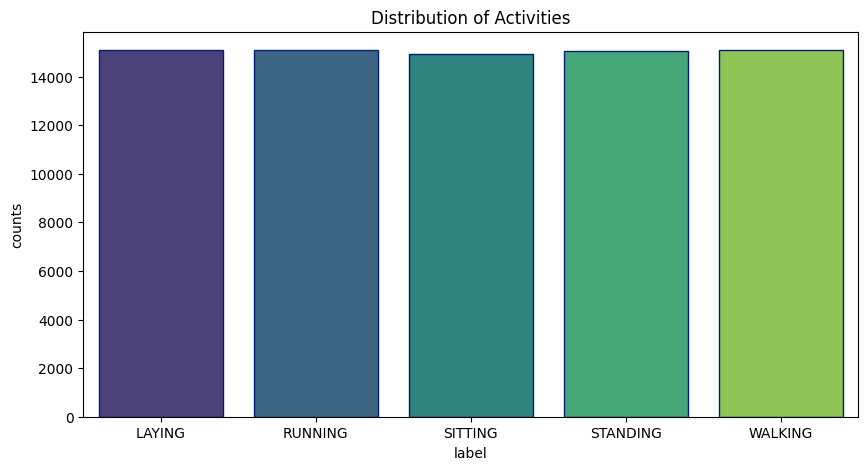

In [45]:
grpd = df.groupby('label').size().reset_index(name='counts')
plt.figure(figsize=(10,5))
sns.barplot(x='label',y='counts',data=grpd , palette='viridis' , edgecolor=sns.color_palette('dark',n_colors=1) , )
plt.title('Distribution of Activities')

plt.show()


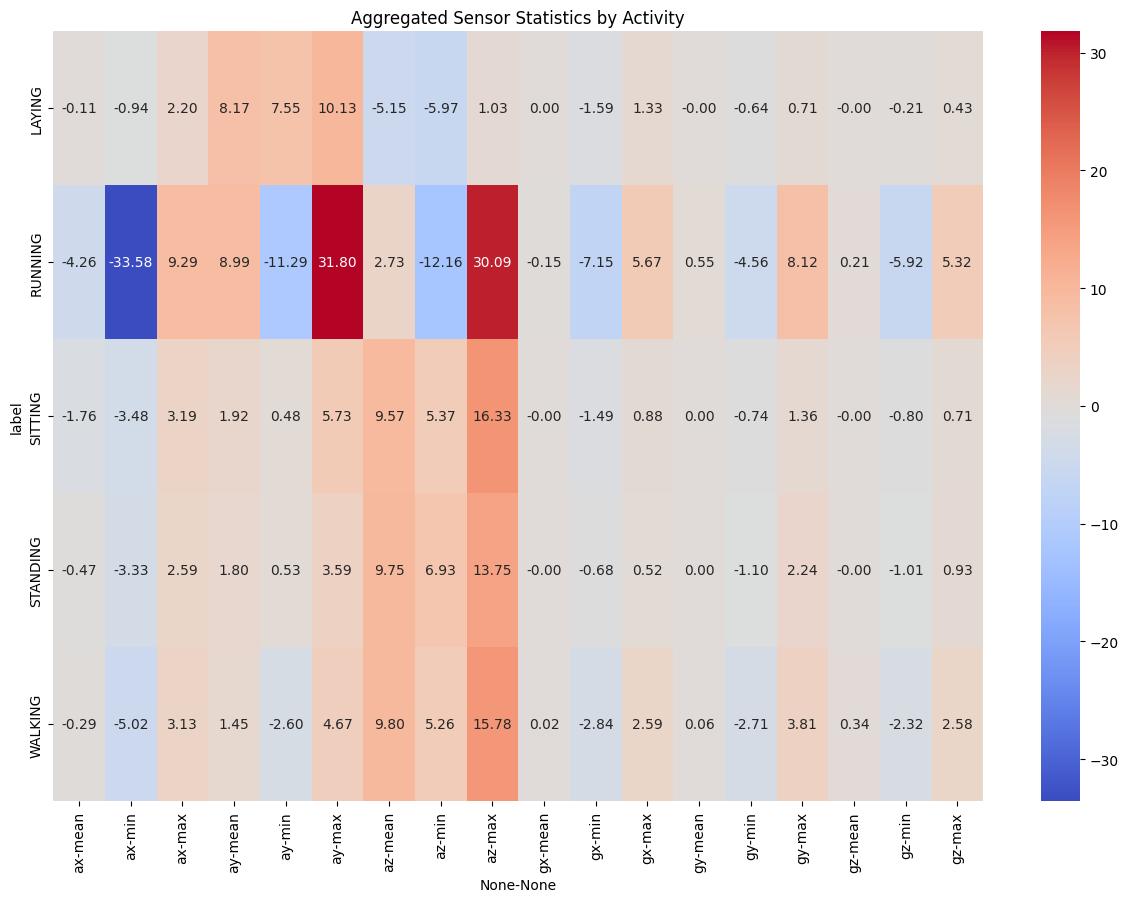

In [46]:
features = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
agg_stats = df.groupby('label')[features].agg(['mean', 'min', 'max'])
plt.figure(figsize=(15,10))
sns.heatmap(agg_stats, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Aggregated Sensor Statistics by Activity')
plt.show()



<Figure size 1000x600 with 0 Axes>

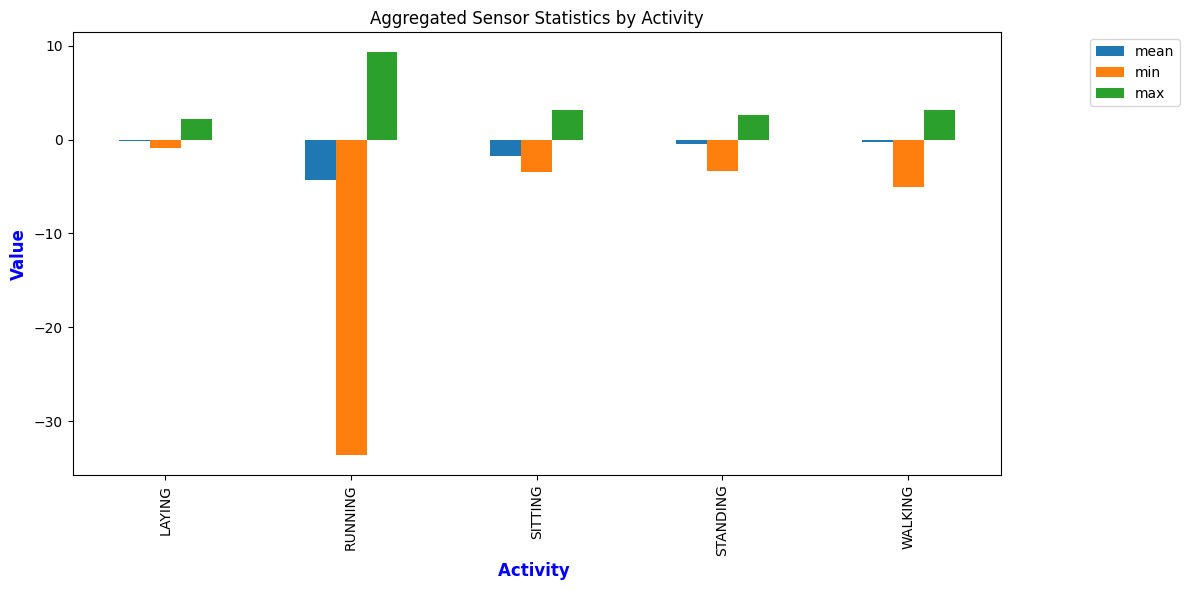

<Figure size 1000x600 with 0 Axes>

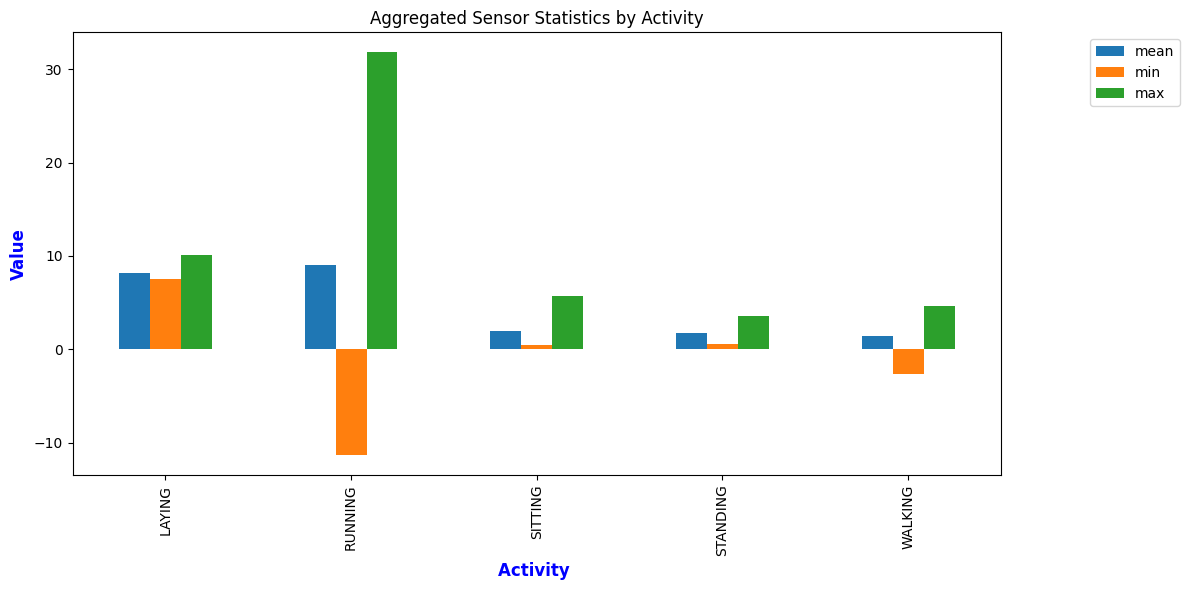

<Figure size 1000x600 with 0 Axes>

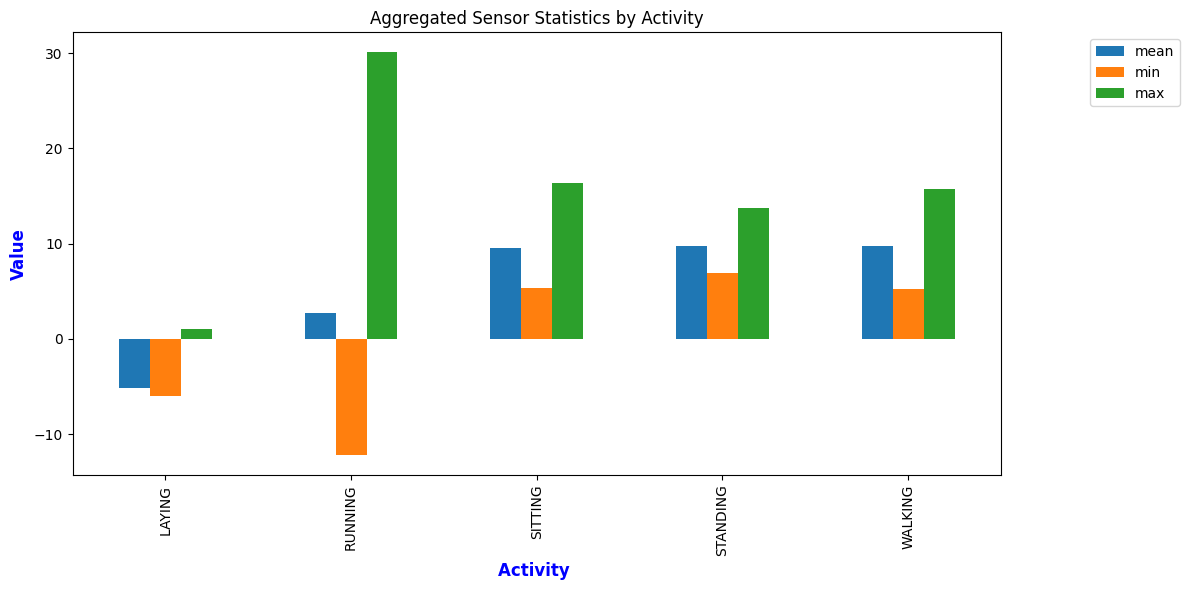

<Figure size 1000x600 with 0 Axes>

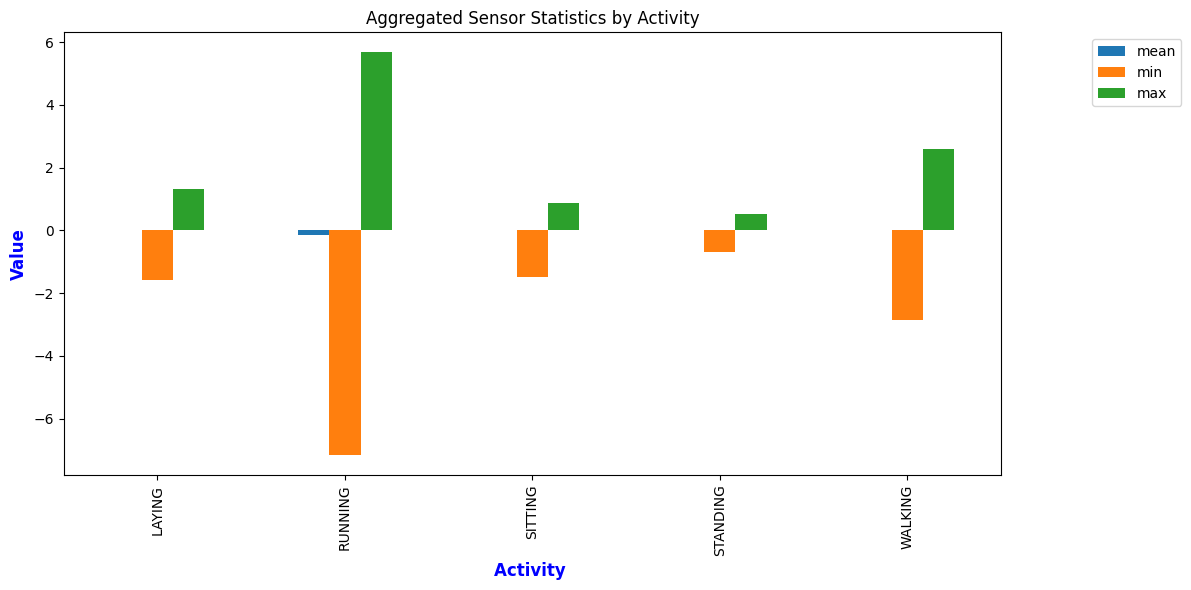

<Figure size 1000x600 with 0 Axes>

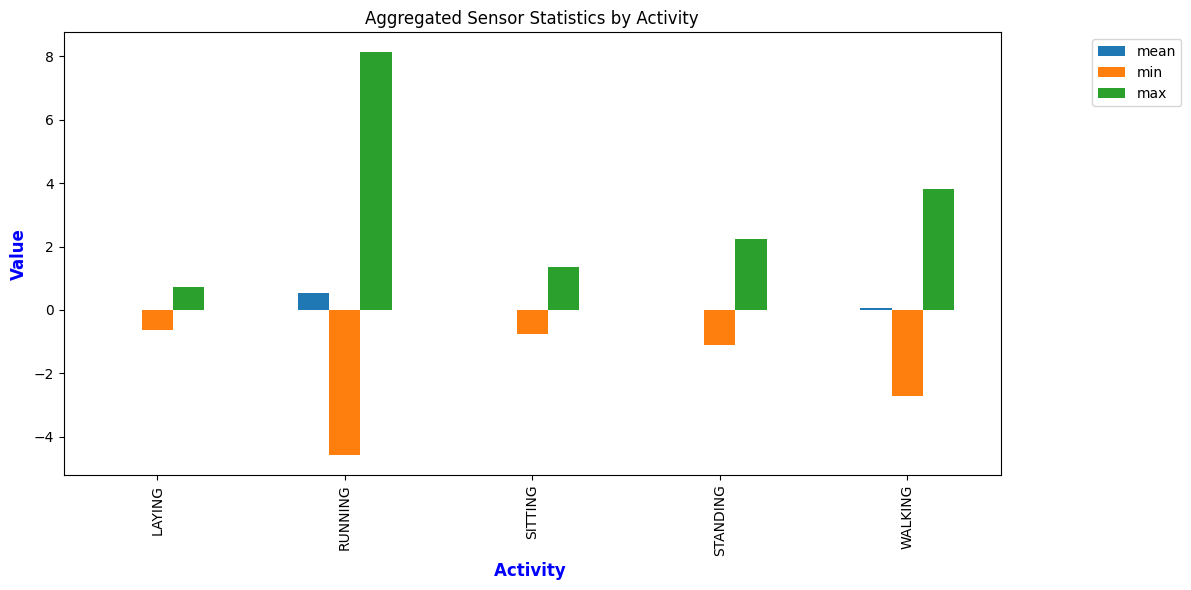

<Figure size 1000x600 with 0 Axes>

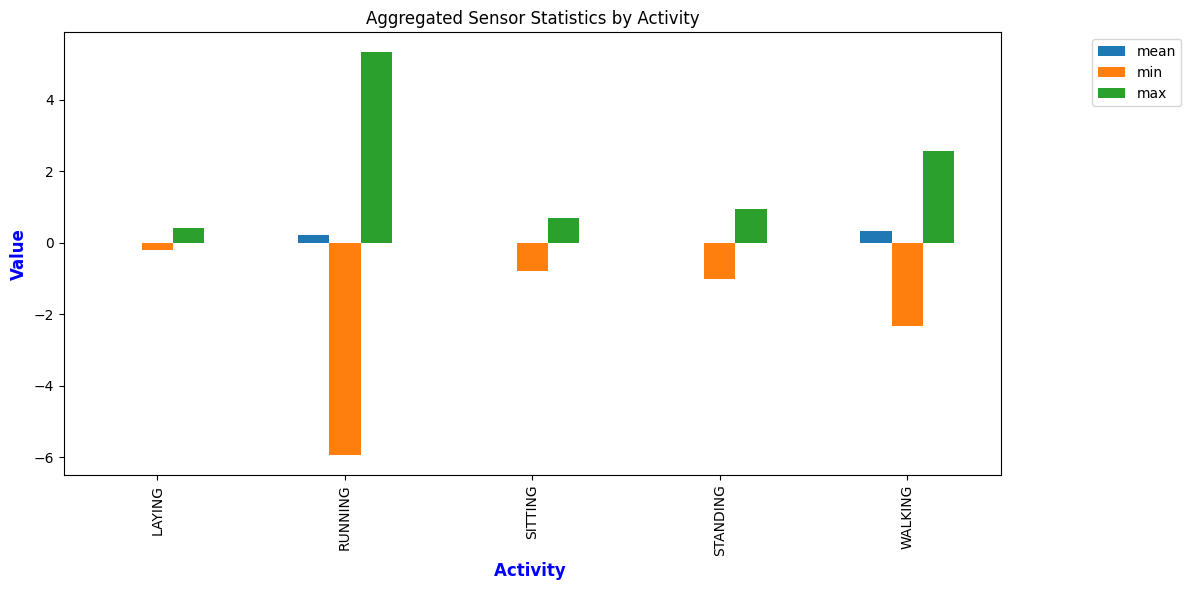

In [47]:

for feature in features:
    plt.figure(figsize=(10,6))
    agg_stats = df.groupby('label')[feature].agg(['mean', 'min', 'max'])
    agg_stats.plot(kind='bar', figsize=(12,6))
    plt.title('Aggregated Sensor Statistics by Activity')
    plt.ylabel('Value' , fontsize=12 , fontweight='bold' , color='blue', )
    plt.xlabel('Activity ' , fontsize=12 , fontweight='bold' , color='blue', )
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()


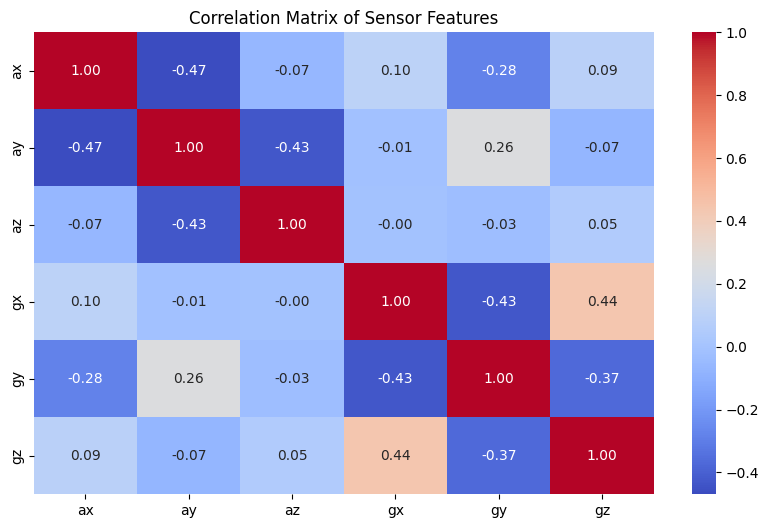

In [48]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Sensor Features')
plt.show()


In [49]:
df.shape

(75263, 7)

Convert dataframe to numpy

In [50]:
from sklearn.preprocessing import MinMaxScaler


df_sorted = df.sort_index()   # keep temporal order


df_features = df_sorted.drop(columns=["label"])
labels = df_sorted["label"]

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_features)

def create_sequences(data, labels, window_size=50, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        # Take features in the current window
        X.append(data[i:i+window_size])

        # Label should be the activity AFTER the window (forecasting)
        y.append(labels.iloc[i+window_size+forecast_horizon-1])
    return np.array(X), np.array(y)




In [51]:
X, y = create_sequences(scaled_features, labels, window_size=100, forecast_horizon=1)

print("X shape:", X.shape)
print("y shape:", y.shape)




X shape: (75163, 100, 6)
y shape: (75163,)


 Balance AFTER windowing

In [52]:

min_count = pd.Series(y).value_counts().min()
balanced_idx = np.hstack([
    np.random.choice(np.where(y==cls)[0], min_count, replace=False)
    for cls in np.unique(y)
])
X = X[balanced_idx]
y = y[balanced_idx]

In [53]:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=42)


***Model Training***

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)



Train: (59708, 100, 6) (59708,)
Test: (14927, 100, 6) (14927,)


Encoding The Label

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

n_classes = len(le.classes_)
print("Classes:", le.classes_)


Classes: ['LAYING' 'RUNNING' 'SITTING' 'STANDING' 'WALKING']


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])





c:\miniconda3\envs\analyst\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
model_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [59]:
history_lstm = model_lstm.fit(X_train, y_train_enc, validation_data=(X_test, y_test_enc),
                              epochs=10, batch_size=64, verbose=1)

Epoch 1/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.3988 - loss: 1.2974 - val_accuracy: 0.3981 - val_loss: 0.9807
Epoch 2/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.4701 - loss: 1.1122 - val_accuracy: 0.6041 - val_loss: 0.7003
Epoch 3/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.6249 - loss: 0.6968 - val_accuracy: 0.5416 - val_loss: 0.6755
Epoch 4/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.6839 - loss: 0.6353 - val_accuracy: 0.8713 - val_loss: 0.5064
Epoch 5/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.7568 - loss: 0.5675 - val_accuracy: 0.6281 - val_loss: 0.7402
Epoch 6/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8492 - loss: 0.3954 - val_accuracy: 0.9406 - val_loss: 0.1824
Epoch 7/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8857 - loss: 0.2932 - val_accuracy: 0.9412 - val_loss: 0.1738
Epoch 8/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8080 - loss: 0.4339 - 

In [60]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])

model_gru.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_gru = model_gru.fit(X_train, y_train_enc, validation_data=(X_test, y_test_enc),
                            epochs=10, batch_size=64, verbose=1 )


Epoch 1/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.5601 - loss: 0.8072 - val_accuracy: 0.5937 - val_loss: 0.7212
Epoch 2/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.5761 - loss: 0.7895 - val_accuracy: 0.8983 - val_loss: 0.8878
Epoch 3/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.7449 - loss: 0.6011 - val_accuracy: 0.7078 - val_loss: 0.6200
Epoch 4/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8420 - loss: 0.4063 - val_accuracy: 0.8980 - val_loss: 0.2455
Epoch 5/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.8830 - loss: 0.2877 - val_accuracy: 0.5956 - val_loss: 0.7110
Epoch 6/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8960 - loss: 0.2553 - val_accuracy: 0.9272 - val_loss: 0.1861
Epoch 7/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9029 - loss: 0.2385 - val_accuracy: 0.9132 - val_loss: 0.1974
Epoch 8/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.8093 - loss: 0.4665 - 

In [61]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
# Evaluate LSTM
y_pred_lstm = model_lstm.predict(X_test).argmax(axis=1)
print("LSTM Performance:")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
LSTM Performance:
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00      2986
     RUNNING       1.00      0.99      1.00      2985
     SITTING       0.98      0.95      0.97      2985
    STANDING       0.86      0.46      0.60      2986
     WALKING       0.61      0.92      0.74      2985

    accuracy                           0.87     14927
   macro avg       0.89      0.87      0.86     14927
weighted avg       0.89      0.87      0.86     14927



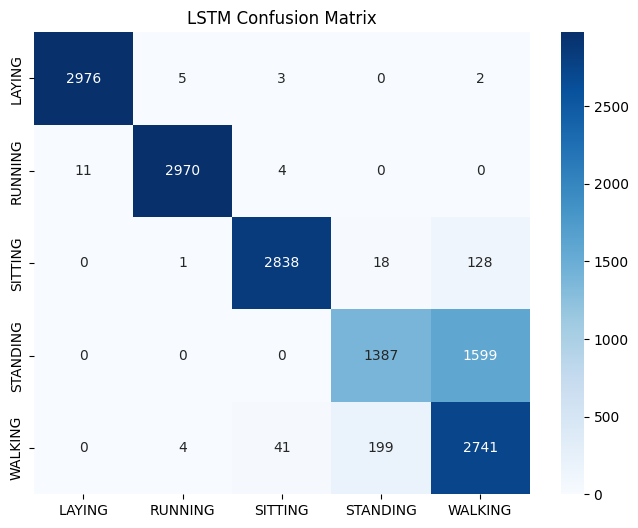

In [63]:
cm = confusion_matrix(y_test_enc, y_pred_lstm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.show()


In [64]:

# Evaluate GRU
y_pred_gru = model_gru.predict(X_test).argmax(axis=1)
print("GRU Performance:")
print(classification_report(y_test_enc, y_pred_gru, target_names=le.classes_))

467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
GRU Performance:
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00      2986
     RUNNING       1.00      1.00      1.00      2985
     SITTING       1.00      0.99      1.00      2985
    STANDING       0.79      0.79      0.79      2986
     WALKING       0.79      0.79      0.79      2985

    accuracy                           0.91     14927
   macro avg       0.91      0.91      0.91     14927
weighted avg       0.91      0.91      0.91     14927



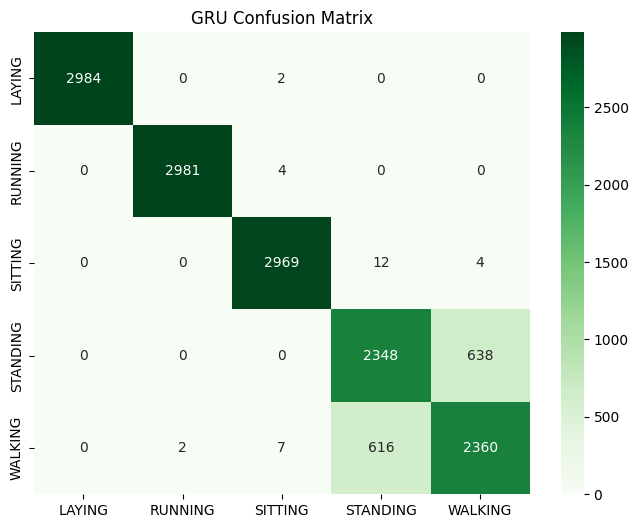

In [65]:

cm = confusion_matrix(y_test_enc, y_pred_gru)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Greens")
plt.title("GRU Confusion Matrix")
plt.show()


In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

X_flat = X.reshape(X.shape[0], -1)

rf = RandomForestClassifier(n_estimators=100, random_state=42)




In [67]:
rf.fit(X_train.reshape(X_train.shape[0], -1), y_train_enc)
y_pred_rf = rf.predict(X_test.reshape(X_test.shape[0], -1))

y_pred_rf_labels = le.inverse_transform(y_pred_rf)
y_test_labels = le.inverse_transform(y_test_enc)

print(y_pred_rf_labels)
print(y_test_labels)

['LAYING' 'STANDING' 'SITTING' ... 'WALKING' 'RUNNING' 'SITTING']
['LAYING' 'STANDING' 'SITTING' ... 'WALKING' 'RUNNING' 'SITTING']


In [68]:
print("Random Forest Performance:")
print(classification_report(y_test_labels, y_pred_rf_labels))


Random Forest Performance:
              precision    recall  f1-score   support

      LAYING       1.00      1.00      1.00      2986
     RUNNING       1.00      1.00      1.00      2985
     SITTING       1.00      1.00      1.00      2985
    STANDING       1.00      0.99      1.00      2986
     WALKING       0.99      1.00      1.00      2985

    accuracy                           1.00     14927
   macro avg       1.00      1.00      1.00     14927
weighted avg       1.00      1.00      1.00     14927



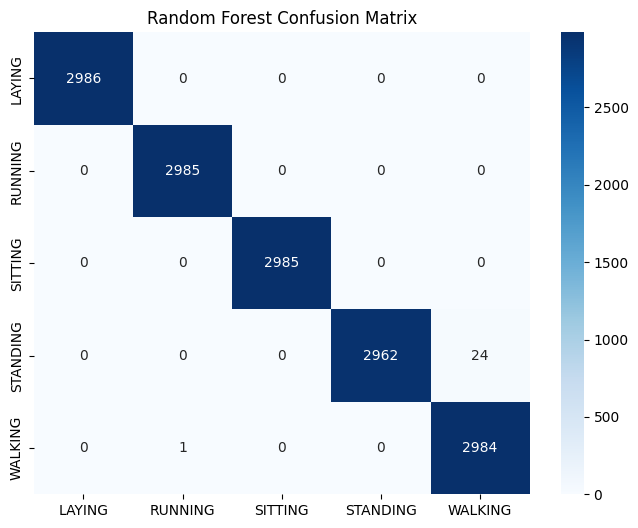

In [69]:
cm_rf = confusion_matrix(y_test_labels, y_pred_rf_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [70]:
X_new = X_test[10]

In [71]:
print("Window shape:", X_new.shape)
print("First 5 timesteps of the window:\n", X_new[:5])

Window shape: (100, 6)
First 5 timesteps of the window:
 [[0.7816502  0.2959273  0.52046458 0.56577775 0.42937246 0.52803892]
 [0.79084259 0.28460279 0.522453   0.56868594 0.43029435 0.54130346]
 [0.79256769 0.27854541 0.52188488 0.56362075 0.40937289 0.53761139]
 [0.78610468 0.27659591 0.52777906 0.55397328 0.38567493 0.52699976]
 [0.78304988 0.27935654 0.52546044 0.55446692 0.37215027 0.52121715]]


In [72]:
X_new = X_new.reshape(1, X_new.shape[0], X_new.shape[1])

In [73]:
y_pred = model_lstm.predict(X_new)
pred_class = y_pred.argmax(axis=1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [74]:
pred_label = le.inverse_transform([pred_class])[0]
print("Predicted Next Activity:", pred_label)


Predicted Next Activity: WALKING


Testing the LSTM Model

In [75]:
X_sample = []
y_sample_labels = []

for label in le.classes_:
    idx = np.where(y_train == label)[0][0]
    X_sample.append(X_train[idx])
    y_sample_labels.append(label)

X_sample = np.array(X_sample)


In [76]:
y_pred_sample = model_lstm.predict(X_sample)
y_pred_sample_classes = y_pred_sample.argmax(axis=1)
y_pred_sample_labels = le.inverse_transform(y_pred_sample_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [77]:
print("Comparing predicted and actual labels for selected samples:")
for actual, predicted in zip(y_sample_labels, y_pred_sample_labels):
    print(f"Actual: {actual}, Predicted: {predicted}")

Comparing predicted and actual labels for selected samples:
Actual: LAYING, Predicted: LAYING
Actual: RUNNING, Predicted: RUNNING
Actual: SITTING, Predicted: SITTING
Actual: STANDING, Predicted: WALKING
Actual: WALKING, Predicted: WALKING
